# Распределение случайной величины

**Случайная величина** — это величина, значение которой зависит от случайных факторов и не может быть предсказано заранее.

**Распределение случайной величины** — это закон, устанавливающий связь между возможными значениями и вероятностями их появления. Для полного описания используются:

- **Функция распределения**  
  $$F(x) = P(X \le x), \quad x \in \mathbb{R}$$
- Для **непрерывных** величин — **плотность вероятности**   

На практике, имея конечную выборку значений, строят **гистограмму**:

1. Диапазон всех значений разбивается на интервалы (bin'ы).
2. Подсчитывается количество наблюдений, попавших в каждый интервал.
3. Относительная частота попадания в интервал  
   $\hat{p}_i = \frac{n_i}{n}$ 
   является **оценкой** вероятности $P(X \in \text{bin}_i)$.

Гистограмма даёт наглядное представление о форме распределения, но имеет ограничения.

- **Зависимость от выбора границ и числа интервалов** — разные разбиения могут дать разную картину.
- **Ступенчатый вид** — не отражает гладкость истинной плотности.
- **Чувствительность к выбросам** и случайным флуктуациям, особенно при малом объёме выборки.
- Невозможность вычислить вероятности для интервалов, которых нет в исходных данных (например, за пределами крайних bin'ов).  

## Аппроксимация теоретическим распределением

Чтобы преодолеть недостатки гистограммы, эмпирические данные **аппроксимируют** (приближают) гладкой теоретической кривой — функцией плотности или функцией распределения известного закона.

### Цели аппроксимации

- **Сглаживание** — устранение случайных шумов выборки.
- **Обобщение** — переход от выборочных данных к свойствам всей генеральной совокупности.
- **Прогнозирование** — возможность вычислять вероятности для любых интервалов, в том числе отсутствующих в выборке.
- **Компактное описание** — вместо таблицы частот используется формула с небольшим числом параметров (например, математическое ожидание $\mu$ и дисперсия $\sigma^2$ для нормального закона).

# Нормальное распределение
На графие ось X показывает значение, ось Y вероятность  
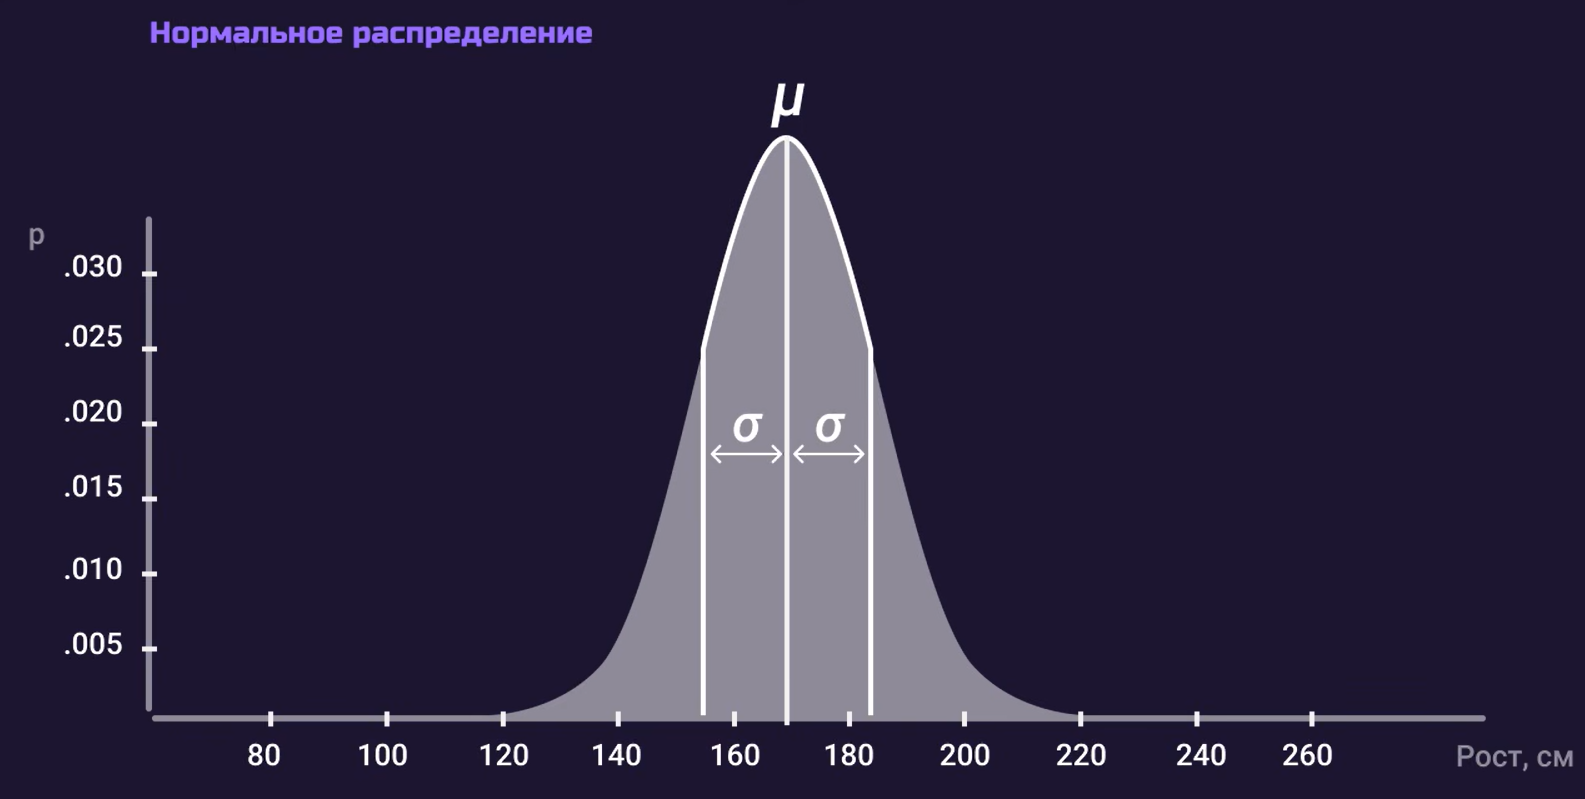  
Площадь графика равна еденице, а площадь графика над выбранным интервалом равна вероятности вхождения случайного значения в этот интервал

Формула плотности нормального распределения:
$$
f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left( -\frac{(x-\mu)^2}{2\sigma^2} \right)
$$  
**$\boldsymbol{\mu}$ - Математическое ожидание** - наиболее ожидаемое значение при многократном повторении испытаний(среднее из всех измеренных)  
**$\boldsymbol{D}$ - Дисперсия** - $$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2$$  
мат ожидание квадрата отклонения случайной величины от среднего  
**$\boldsymbol{\sigma}$ - Среднекватратическое(стндартное) отклонение** -корень из дисперсии  определяет ширину графика и показывает насколько в среднем разбросаны значения от среднего 


# Условная вероятность и формула Байеса

## Условная вероятность
$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0$$

События $A$ и $B$ **независимы** $\iff$ $P(A \cap B) = P(A) \cdot P(B)$ $\iff$ $P(A \mid B) = P(A)$.

## Формула полной вероятности
Если $B_1, \dots, B_n$ — разбиение пространства исходов (попарно несовместны и покрывают всё):
$$P(A) = \sum_{i=1}^{n} P(A \mid B_i) \cdot P(B_i)$$

## Формула Байеса
$$P(B_k \mid A) = \frac{P(A \mid B_k) \cdot P(B_k)}{\sum_{i=1}^{n} P(A \mid B_i) \cdot P(B_i)}$$

### Классический пример (важно понимать интуицию!)
Болезнь у 1% населения. Тест: чувствительность $P(\text{тест}+ \mid \text{болен}) = 0.99$, специфичность $P(\text{тест}- \mid \text{здоров}) = 0.95$.
$$P(\text{болен} \mid \text{тест}+) = \frac{0.99 \cdot 0.01}{0.99 \cdot 0.01 + 0.05 \cdot 0.99} \approx 0.167$$

Положительный тест (точность которого «99%») даёт лишь **~17%** вероятности болезни — из-за редкости события. Аналогия с ML: точный классификатор на редком классе всё равно даёт низкий Precision.

## Зачем это в ML
- **Наивный байесовский классификатор** строится прямо на этой формуле.
- Апостериорная вероятность $P(y \mid x)$ — основа вероятностных моделей (логистическая регрессия, генеративные модели).
- Чувствительность $\approx$ recall, специфичность $\approx$ TNR — это те же понятия, что precision/recall только с другого ракурса.

# Дискретные распределения (шпаргалка)

## Бернулли $\mathrm{Bern}(p)$
- Значения $\{0, 1\}$; $P(X = 1) = p$.
- $E[X] = p$, $\mathrm{Var}(X) = p(1-p)$.
- **В ML:** одно бинарное событие (клик/не клик) — база бинарной классификации.

## Биномиальное $\mathrm{Bin}(n, p)$
- Число успехов в $n$ независимых испытаниях Бернулли: $X = \xi_1 + \dots + \xi_n$.
- $P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$.
- $E[X] = np$, $\mathrm{Var}(X) = np(1-p)$.
- **В ML:** число конверсий из $n$ показов.

## Пуассон $\mathrm{Pois}(\lambda)$
- Число событий редкого потока (заявки в час, сбои в день), $\lambda > 0$.
- $P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$.
- $E[X] = \mathrm{Var}(X) = \lambda$ — **матожидание равно дисперсии**.
- Предел бинома при $n \to \infty$, $p \to 0$, $np \to \lambda$.

## Таблица для быстрого повторения
| Распределение | Параметры | $E[X]$ | $\mathrm{Var}(X)$ |
|---|---|---|---|
| $\mathrm{Bern}(p)$ | $p \in (0,1)$ | $p$ | $p(1-p)$ |
| $\mathrm{Bin}(n, p)$ | $n \in \mathbb{N}$, $p$ | $np$ | $np(1-p)$ |
| $\mathrm{Pois}(\lambda)$ | $\lambda > 0$ | $\lambda$ | $\lambda$ |

# Непрерывные распределения (шпаргалка)

## Равномерное $U(a, b)$
- Плотность $f(x) = \frac{1}{b-a}$ на $[a, b]$, $f = 0$ вне отрезка.
- $E[X] = \frac{a+b}{2}$, $\mathrm{Var}(X) = \frac{(b-a)^2}{12}$.
- **В ML:** случайная инициализация весов, сэмплирование гиперпараметров.

## Экспоненциальное $\mathrm{Exp}(\lambda)$
- Плотность $f(x) = \lambda e^{-\lambda x}$, $x \ge 0$.
- $E[X] = \frac{1}{\lambda}$, $\mathrm{Var}(X) = \frac{1}{\lambda^2}$.
- **Отсутствие памяти:** $P(X > s + t \mid X > t) = P(X > s)$ — время ожидания «без старения». Время между событиями пуассоновского потока всегда экспоненциально.

## Стьюдента $t_\nu$ и Хи-квадрат $\chi^2_k$
- $t$: нормирует выборочное среднее при неизвестной дисперсии $\frac{\bar X - \mu}{s / \sqrt{n}} \sim t_{n-1}$. При $\nu \to \infty$ превращается в стандартное нормальное.
- $\chi^2_k$: сумма квадратов $k$ независимых стандартных нормальных $X_1^2 + \dots + X_k^2$. Нужна для проверки связей между признаками.

## Как прикинуть закон по данным
- Считаем число событий за интервал → Пуассон/экспонента.
- Симметричный разброс вокруг среднего (ошибки измерения) → нормальное.
- Неотрицательная величина с «тяжёлым хвостом» (доходы, цены) → логнормальное / Парето.
- Всегда сначала — **гистограмма**, распределение подбираем под её форму.

# Матожидание, дисперсия, ковариация, корреляция

## Матожидание
- $E[X] = \int x f(x)\, dx$ (непр.) или $E[X] = \sum x p(x)$ (дискр.).
- **Линейность (всегда, без всяких условий):** $E[aX + bY + c] = aE[X] + bE[Y] + c$.
- $E[XY] = E[X]E[Y]$, только если $X$ и $Y$ **независимы**.

## Дисперсия
- $\mathrm{Var}(X) = E[(X - EX)^2] = E[X^2] - (EX)^2$.
- $\mathrm{Var}(aX + b) = a^2 \mathrm{Var}(X)$ — сдвиг дисперсию не меняет.
- $\mathrm{Var}(X + Y) = \mathrm{Var}(X) + \mathrm{Var}(Y) + 2\,\mathrm{Cov}(X, Y)$; для независимых — просто сумма.

## Ковариация и корреляция
- $\mathrm{Cov}(X, Y) = E[(X - EX)(Y - EY)] = E[XY] - EX \cdot EY$.
- Корреляция $\rho = \frac{\mathrm{Cov}(X, Y)}{\sigma_X \sigma_Y} \in [-1, 1]$ — нормированная ковариация.
- $\rho = 0$ → некоррелированы. **Из независимости следует некоррелированность, обратное — НЕ верно.** Контрпример: $X \sim U(-1,1)$, $Y = X^2$ — зависимы, но $\mathrm{Cov} = 0$.

## Полезно для ML
- Ковариационная матрица $\Sigma$ — показывает линейные связи между всеми признаками.
- **Мультиколлинеарность** (сильно коррелированные признаки) → нестабильные веса линейной модели → сигнал для регуляризации или отбора признаков.
- Корреляция признака с таргетом — первый фильтр значимости в EDA.

# Закон больших чисел и ЦПТ

## ЗБЧ (форма Хинчина)
Для независимых одинаково распределённых $X_1, \dots, X_n$ с конечным $E X = \mu$:
$$\frac{1}{n}\sum_{i=1}^{n} X_i \:\to\: \mu \ \text{(по вероятности)},\quad n \to \infty$$

Выборочное среднее сходится к матожиданию: больше данных → ближе к $\mu$.

## ЦПТ (Ляпунова / Линдеберга–Леви)
Для тех же $X_i$ с конечными $\mu$ и $\sigma^2$:
$$\frac{\bar X_n - \mu}{\sigma / \sqrt{n}} \:\to\: N(0, 1) \ \text{(по распределению)}$$

Сумма/среднее большого числа слабозависимых величин ≈ нормальна, **каково бы ни было исходное распределение**.

## Что выносим на практику
- **Стандартная ошибка среднего** $\mathrm{SE}(\bar X) = \sigma / \sqrt{n}$ — разброс оценки убывает с корнем из числа наблюдений.
- Ошибка модели на валидации — это тоже среднее по объектам → её колебания подчиняются ЦПТ. Рост выборки уменьшает разброс метрики: «собери больше данных и оценка метрики станет надёжнее».
- Отсюда же квантили $z$ (1.96 для 95%) в доверительных интервалах.

# Математическая статистика: точечные оценки

## Свойства оценок
Оценка $\hat\theta$ — функция выборки, приближающая неизвестный параметр $\theta$.
- **Несмещённая:** $E[\hat\theta] = \theta$ — в среднем не ошибается.
- **Состоятельная:** $\hat\theta \to \theta$ при $n \to \infty$ (по вероятности).
- **Эффективная:** минимальная дисперсия среди несмещённых.

## Выборочная дисперсия: почему делим на $n-1$
- $\bar X$ — несмещённая оценка $\mu$.
- Смещённая дисперсия $\frac{1}{n}\sum (X_i - \bar X)^2$ систематически **занижает** $\sigma^2$: $E[\dots] = \frac{n-1}{n}\sigma^2$.
- Отсюда несмещённая: $s^2 = \frac{1}{n-1}\sum_{i=1}^{n} (X_i - \bar X)^2$.
- Интуиция: одна степень свободы «потрачена» на оценку $\bar X$; разброс вокруг оценённого среднего всегда чуть меньше, чем вокруг истинного.

## Метод максимального правдоподобия (MLE)
$$\hat\theta_{MLE} = \arg\max_{\theta} \ln L(\theta), \qquad L(\theta) = \prod_{i=1}^{n} f(x_i \mid \theta)$$

- Логарифм превращает произведение в сумму — удобно дифференцировать; точка максимума не меняется.
- **Пример:** для нормального распределения при известном $\sigma$ получается $\hat\mu_{MLE} = \bar X$.
- **Связь с ML:** логистическая регрессия = MLE для модели Бернулли; регрессия по MSE = MLE для нормального шума.
- Регуляризация — это априор: **L2 = MLE + нормальный априор** (байесовский MAP), **L1 = MLE + априор Лапласа**.

## Метод моментов
Приравниваем теоретические моменты выборочным: $E[X] = \bar X$, $E[X^2] = \frac{1}{n}\sum X_i^2$, решаем систему относительно параметров.

# Доверительные интервалы и проверка гипотез

## Доверительный интервал для среднего
- $\sigma$ известна: $\bar X \pm z_{\alpha/2}\, \frac{\sigma}{\sqrt{n}}$ (для 95% $z \approx 1.96$).
- $\sigma$ неизвестна: $\bar X \pm t_{n-1;\, \alpha/2}\, \frac{s}{\sqrt{n}}$ — Стьюдент; при больших $n$ ≈ нормальный.
- Смысл: в ~95% повторных экспериментов интервал накроет $\mu$. Это свойство **процедуры**, а не конкретного числа.

## Проверка гипотез
- $H_0$ (нулевая) — «ничего не изменилось», $H_1$ — альтернатива.
- **p-value** = вероятность получить данные не менее экстремальные **при условии, что $H_0$ верна**.
- p-value $< \alpha$ (обычно 0.05) → «статистически значимо», отвергаем $H_0$.

## Ошибки I и II рода
| Решение | $H_0$ верна | $H_1$ верна |
|---|---|---|
| отвергли $H_0$ | **Ошибка I рода** (вероятность $\alpha$) | ✅ верно |
| приняли $H_0$ | ✅ верно | **Ошибка II рода** (вероятность $\beta$) |

- Мощность $= 1 - \beta$ — способность обнаружить реальный эффект.
- Уменьшить обе ошибки сразу нельзя без роста $n$; при фиксированной выборке меняем только баланс (порог/α).

## Зачем в ML
- **A/B-тесты:** статистическая значимость отличия метрики (CTR, доход) между вариантами.
- Доверительный интервал на метрику модели (ROC-AUC) — насколько оценка точна.
- p-value как фильтр признаков: осторожно — при проверке многих признаков растёт число ложных значимостей (нужна коррекция: Бонферрони, FDR).

# Оптимизация для ML (кратко)

## Задача
$$\min_{w} L(w)$$
где $L$ — функционал ошибки модели, $w$ — параметры.

## Выпуклость
$f$ выпукла, если для любых $x, y$ и $\lambda \in [0, 1]$:
$$f(\lambda x + (1-\lambda) y) \le \lambda f(x) + (1-\lambda) f(y)$$

- **Ключевой факт:** у выпуклой функции любой локальный минимум — глобальный.
- В ML выпуклы: MSE, логистическая потеря, ридж-регрессия, SVM. Нейросети **не выпуклы** (много локальных минимумов и седловых точек).

## Необходимое условие минимума
Для дифференцируемой выпуклой $f$: $w^*$ — точка минимума $\iff \nabla f(w^*) = 0$.
Отсюда нормальные уравнения линейной регрессии $w = (X^\top X)^{-1} X^\top y$.

## Метод множителей Лагранжа
Минимум $f(x)$ при ограничении $g(x) = 0$:
$$\mathcal{L}(x, \lambda) = f(x) + \lambda g(x), \qquad \nabla \mathcal{L} = 0$$

Встречается в ML: SVM (максимум отступа при ограничении на норму весов), PCA (максимум дисперсии проекции при $\|w\| = 1$).

## Градиентный спуск
$$w_{k+1} = w_k - \eta_k \nabla L(w_k)$$

- $\eta_k$ — learning rate: слишком большой «перепрыгивает» минимум, слишком малый — медленно сходится.
- Варианты: SGD (по одному объекту), mini-batch, momentum, RMSprop, Adam.
- Подробно с формулами и примерами — в конспектах лекций 2–3 (Соколов, «Линейная регрессия»).